In [32]:
import nilearn as nl
import numpy as np
import matplotlib
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import openpyxl as xl

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask, unmask
from nilearn.image import index_img, resample_to_img, math_img, mean_img
from nilearn.plotting import plot_stat_map, show
from nilearn import image, masking

from nilearn import plotting

from nilearn.datasets import load_mni152_brain_mask

from pandas import read_excel


In [2]:
#
#   Constants
#

epidata_dir = "./testData/fmri"
confounds_dir = "./testData/confounds/"

testSubject = 221
# Define subjects
participants = [49]#, 58, 95, 115, 127, 181, 186, 190, 191, 200, 201] + list(range(206, 238)) + list(range(239, 254))
#exclude subj 238, see paper

onsets = [44.7,62.6,76.4,110,145.4,154.6,182.7,199,213.8,232,243,263,281.2,302.5,312,331.7,363.7,376.6,390,406,421,438.5]
durations = [17.9,13.8,33.6,35.4,9.2,28.1,16.3,14.8,18.2,11,20,18.2,21.3,9.5,19.7,32,12.9,13.4,16,15,17.5,14.5]
eventNames = ["1","2","3","4","5","6","7","8","9","10","11","12","13","14","15","16","17","18","19","20","21","22"]

segmentFileDF = pd.read_excel("testData/foundationScores/shapessocial_transcript_segment_MFT_MAC.xlsx")

segmentFileDF['familyMAC_filterAbovePointTwo']  = segmentFileDF['seg_MAC_a_family_virtue'].apply(lambda x: x if x >= .2 else 0.00001)

segmentValues = segmentFileDF[['segment',
                               'seg_MFT_a_care_virtue',
                               'seg_MFT_a_fairness_virtue',
                               'seg_MFT_a_loyalty_virtue',
                               'seg_MFT_a_authority_virtue',
                               'seg_MFT_a_sanctity_virtue',
                               'seg_MFT_a_care_vice',
                               'seg_MFT_a_fairness_vice',
                               'seg_MFT_a_loyalty_vice',
                               'seg_MFT_a_authority_vice',
                               'seg_MFT_a_sanctity_vice',
                               'seg_MAC_a_fairness_virtue',
                               'seg_MAC_a_group_virtue',
                               'seg_MAC_a_deference_virtue',
                               'seg_MAC_a_heroism_virtue',
                               'seg_MAC_a_reciprocity_virtue',
                               'seg_MAC_a_family_virtue',
                               'seg_MAC_a_property_virtue',
                               'seg_MAC_a_fairness_vice',
                               'seg_MAC_a_group_vice',
                               'seg_MAC_a_deference_vice',
                               'seg_MAC_a_heroism_vice',
                               'seg_MAC_a_reciprocity_vice',
                               'seg_MAC_a_family_vice',
                               'seg_MAC_a_property_vice',
                               'familyMAC_filterAbovePointTwo']]



eventFoundations = segmentValues.drop_duplicates(subset=['segment'], keep='first', ignore_index=True)
eventFoundations = eventFoundations.iloc[:,1:]


In [3]:
#
#   Helper functions
#

def load_epi_data_social(sub):
    # Load MRI file (in Nifti format)
    epi_in = os.path.join(epidata_dir,"sub-%03d_task-shapessocial_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii" % (sub))
    epi_data_social = nib.load(epi_in)
    print("Loading data from %s" % (epi_in))
    return epi_data_social

def load_epi_data_physical(sub):
    # Load MRI file (in Nifti format)
    epi_in = os.path.join(epidata_dir,"sub-%03d_task-shapesphysical_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii" % (sub))
    epi_data_physical = nib.load(epi_in)
    print("Loading data from %s" % (epi_in))
    return epi_data_physical


Loading data from ./testData/fmri/sub-221_task-shapessocial_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii
trial: 0
trial: 1
trial: 2
trial: 3
trial: 4
trial: 5
trial: 6
trial: 7
trial: 8
trial: 9
trial: 10
trial: 11
trial: 12
trial: 13
trial: 14
trial: 15
trial: 16
trial: 17
trial: 18
trial: 19
trial: 20
trial: 21


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/first_level/first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


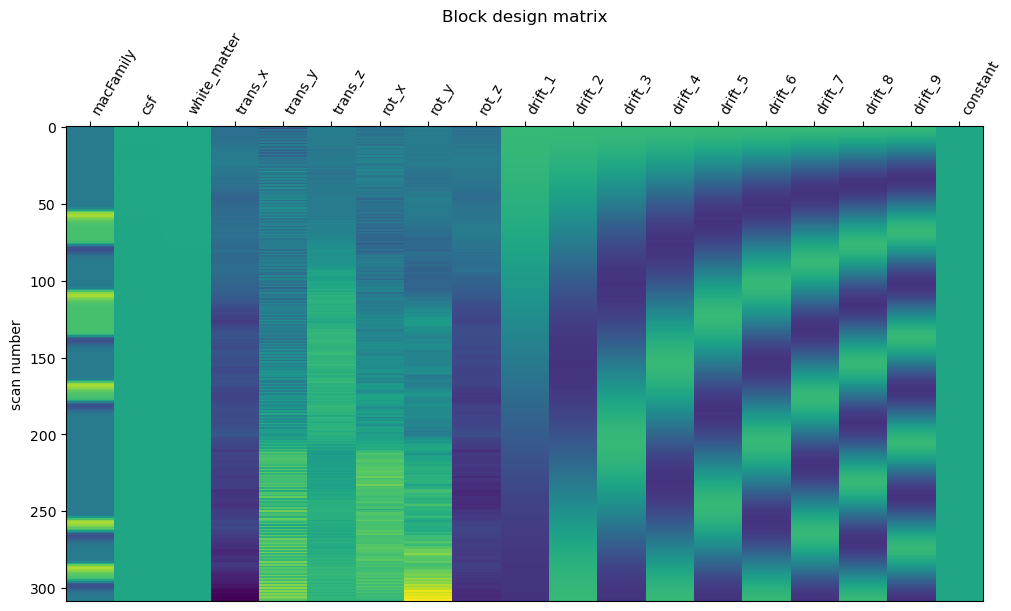

In [18]:
#
#   Data transform
#

epi_data_socialNIFTI = load_epi_data_social(testSubject)

events = pd.DataFrame( {"trial_type":sorted([int(x) for x in eventNames]),"onset":onsets,"duration":durations})
fname1 = "sub-%03d_task-shapessocial_desc-confounds_regressors.tsv" % testSubject
confoundsAll = confounds_dir + fname1

df = pd.read_csv(confoundsAll, sep='\t')
confound_file1 = df[['csf', 'white_matter', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']].to_numpy()

# use only events from above .2 MAC family values
modulationValues = eventFoundations[ 'familyMAC_filterAbovePointTwo']

## only keep the rows with modulationValues above .2
for Trial in range(len(modulationValues)):

    print('trial:', Trial)
    
    if modulationValues[Trial] < .2:

        events = events.drop(Trial)

events['trial_type'] = 'macFamily'

# Make an average
mean_img = image.mean_img(epi_data_socialNIFTI, copy_header=True)
mask = masking.compute_epi_mask(mean_img, lower_cutoff=0.2, upper_cutoff=0.85, opening=3, connected=True)

# Clean and smooth data
epi_data_socialNIFTI = image.clean_img(epi_data_socialNIFTI, standardize=False)
epi_data_socialNIFTI = image.smooth_img(epi_data_socialNIFTI, 6.0)

# get fdata
epi_data_social = epi_data_socialNIFTI.get_fdata()

frame_times = (
    np.arange(epi_data_social.shape[3] ) * 1.5
)

#baseline first level model

X_base = make_first_level_design_matrix(
    frame_times,
    events,
    add_regs=confound_file1,
    add_reg_names=['csf', 'white_matter', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z'],
    hrf_model='glover',
)

FM1 = FirstLevelModel(mask_img=mask)
FM1 = FM1.fit(epi_data_socialNIFTI, design_matrices=X_base)


#contrast first level model

# Let's compare it to the unmodulated block design
fig, (ax1) = plt.subplots(
    figsize=(10, 6), nrows=1, ncols=1, constrained_layout=True
)

plot_design_matrix(X_base, axes=ax1)
ax1.set_title("Block design matrix", fontsize=12)
plt.show()


In [36]:
## create contrast image
contrast_name = "macFamily"

z_map = FM1.compute_contrast(
    contrast_name,
    output_type="z_score"  # Can be ‘z_score’, ‘stat’, ‘p_value’, ‘effect_size’, ‘effect_variance’ or ‘all’
)

# Apply mask to z_map
masked_data = apply_mask(z_map, mask)      
z_map_masked = unmask(masked_data, mask)  

# save contrast image for the testsubject (to be used at second level)
z_map_masked.to_filename("contrast_macFamily.nii.gz")



/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_6006/188460485.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_epi = mean_img(epi_data_socialNIFTI)


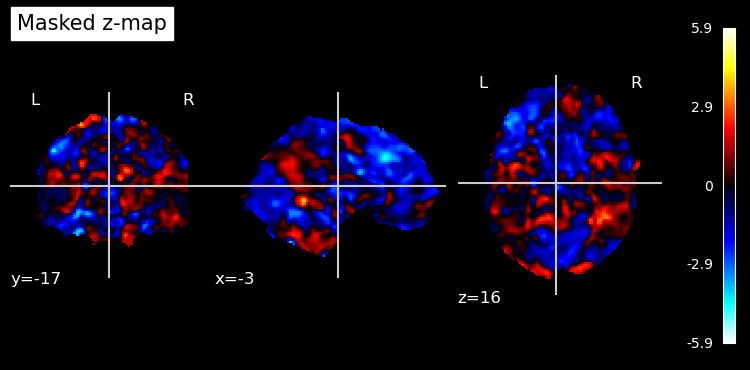

In [37]:
mean_epi = mean_img(epi_data_socialNIFTI)
plotting.plot_stat_map(z_map_masked, bg_img=mean_epi, title="Masked z-map")